# Aprendizaje Automático

---




**Nombre:** Verónica Nathaly Alvarado Reyes

**Curso:** CDDEIA-ELNO-4-2

**MODELO DE REGRESION LOGISTICA**

In [ ]:
# Importar librerías principales para manejo de datos y visualización

import numpy as np  # Permite realizar operaciones numéricas y trabajar con arreglos
import pandas as pd  # Permite manipular datos en forma de tablas o DataFrames

import matplotlib.pyplot as plt  # Librería para crear gráficos básicos
import seaborn as sns  # Librería para gráficos estadísticos más visuales y ordenados


# Importar el dataset de cáncer de mama incluido en sklearn
from sklearn.datasets import load_breast_cancer


# Importar herramientas para dividir datos, validación cruzada y búsqueda de hiperparámetros
from sklearn.model_selection import (
    train_test_split,      # Divide los datos en entrenamiento y prueba
    cross_val_score,       # Evalúa el modelo usando validación cruzada
    GridSearchCV,          # Busca los mejores hiperparámetros probando todas las combinaciones posibles
    RandomizedSearchCV     # Busca hiperparámetros probando combinaciones aleatorias
)


# Importar herramienta para escalar o normalizar las variables numéricas
from sklearn.preprocessing import StandardScaler


# Importar el modelo de Regresión Logística para clasificación
from sklearn.linear_model import LogisticRegression


# Importar métricas para evaluar el rendimiento del modelo de clasificación
from sklearn.metrics import (
    confusion_matrix,       # Crea la matriz de confusión
    classification_report,  # Muestra precisión, recall, F1-score y soporte por clase
    precision_score,        # Calcula la precisión del modelo
    recall_score,           # Calcula el recall o sensibilidad del modelo
    f1_score,               # Calcula el F1-score, equilibrio entre precisión y recall
    roc_auc_score,          # Calcula el área bajo la curva ROC
    roc_curve               # Obtiene los valores para graficar la curva ROC
)

In [ ]:
# Cargar el dataset de cáncer de mama incluido en la librería sklearn
data = load_breast_cancer()

# Guardar las variables independientes o características del dataset
# Estas variables son las mediciones utilizadas para entrenar el modelo
X = data.data

# Guardar la variable dependiente o etiqueta del dataset
# Esta indica la clase de cada muestra: tumor benigno o maligno
y = data.target

# Mostrar el número total de muestras o registros que tiene el dataset
print("Número de muestras:", X.shape[0])

# Mostrar el número total de características o columnas predictoras
print("Número de características:", X.shape[1])

Número de muestras: 569
Número de características: 30


In [ ]:
# División del dataset en datos de entrenamiento y datos de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Variables independientes o características del modelo
    y,                  # Variable objetivo o etiqueta que se desea predecir
    test_size=0.2,      # Se reserva el 20% de los datos para prueba y el 80% para entrenamiento
    random_state=42,    # Permite obtener siempre la misma división de datos al ejecutar el código
    stratify=y          # Mantiene la misma proporción de clases en entrenamiento y prueba
)

In [ ]:
# Escalado o normalización de los datos

# Crear un objeto StandardScaler para estandarizar las variables numéricas
# Esto transforma los datos para que tengan media 0 y desviación estándar 1
scaler = StandardScaler()

# Ajustar el escalador usando solo los datos de entrenamiento
# Luego transforma X_train con esos valores calculados
X_train = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando el mismo escalador ajustado con X_train
# No se usa fit_transform en X_test para evitar fuga de información
X_test = scaler.transform(X_test)

In [ ]:
# Creación del modelo de clasificación

# Se crea un modelo de Regresión Logística
modelo = LogisticRegression(max_iter=5000)

# Entrenar el modelo usando los datos de entrenamiento
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
# Predicción del modelo con los datos de prueba

# Usar el modelo entrenado para predecir la clase de cada muestra en X_test
# El resultado será 0 o 1, según la clasificación del tumor
y_pred = modelo.predict(X_test)

# Obtener las probabilidades estimadas por el modelo para cada clase
# [:, 1] selecciona la probabilidad de la clase 1
# En este dataset, la clase 1 corresponde a tumor benigno
y_prob = modelo.predict_proba(X_test)[:, 1]

**MATRIZ DE CONFUSION**

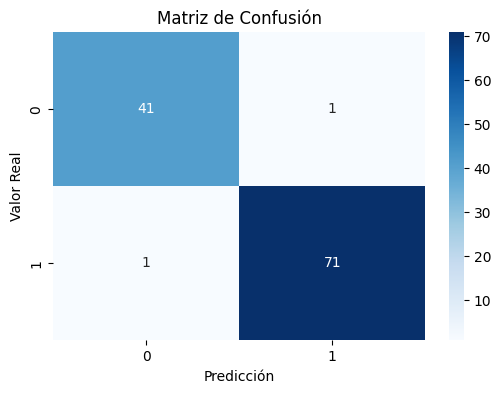

In [ ]:
# Crear la matriz de confusión comparando los valores reales con las predicciones
cm = confusion_matrix(y_test, y_pred)

# Definir el tamaño del gráfico
plt.figure(figsize=(6, 4))

# Crear un mapa de calor para visualizar la matriz de confusión
sns.heatmap(
    cm,             # Matriz de confusión que se va a graficar
    annot=True,     # Muestra los valores dentro de cada celda
    fmt="d",        # Indica que los valores se mostrarán como números enteros
    cmap="Blues"    # Define la escala de colores del gráfico
)

# Agregar título al gráfico
plt.title("Matriz de Confusión")

# Etiqueta del eje X: valores que predijo el modelo
plt.xlabel("Predicción")

# Etiqueta del eje Y: valores reales del conjunto de prueba
plt.ylabel("Valor Real")

# Mostrar el gráfico final
plt.show()

In [ ]:
# Interpretación de la matriz de confusión

# Separar los valores de la matriz de confusión en cuatro partes:
# TN: Verdaderos negativos
# FP: Falsos positivos
# FN: Falsos negativos
# TP: Verdaderos positivos
tn, fp, fn, tp = cm.ravel()

# Mostrar la cantidad de verdaderos negativos
# Casos negativos que el modelo clasificó correctamente como negativos
print("TN:", tn)

# Mostrar la cantidad de falsos positivos
# Casos negativos que el modelo clasificó incorrectamente como positivos
print("FP:", fp)

# Mostrar la cantidad de falsos negativos
# Casos positivos que el modelo clasificó incorrectamente como negativos
print("FN:", fn)

# Mostrar la cantidad de verdaderos positivos
# Casos positivos que el modelo clasificó correctamente como positivos
print("TP:", tp)

TN: 41
FP: 1
FN: 1
TP: 71


**CALCULOS: Precisión, Recall, F1-Score y AUC-ROC**

In [ ]:
# Cálculo de métricas de evaluación del modelo

# Calcular la precisión del modelo
precision = precision_score(y_test, y_pred)

# Calcular el recall o sensibilidad del modelo
# El recall indica cuántos casos positivos reales fueron identificados correctamente
recall = recall_score(y_test, y_pred)

# Calcular el F1 Score
# Esta métrica combina precisión y recall en un solo valor
f1 = f1_score(y_test, y_pred)

# Calcular el área bajo la curva ROC
# El AUC ROC mide la capacidad del modelo para diferenciar entre las clases
auc = roc_auc_score(y_test, y_prob)

# Mostrar el valor de precisión obtenido
print("Precision:", precision)

# Mostrar el valor de recall obtenido
print("Recall:", recall)

# Mostrar el valor de F1 Score obtenido
print("F1 Score:", f1)

# Mostrar el valor de AUC ROC obtenido
print("AUC ROC:", auc)

Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
AUC ROC: 0.9953703703703703


In [ ]:
# Mostrar un reporte completo de clasificación del modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



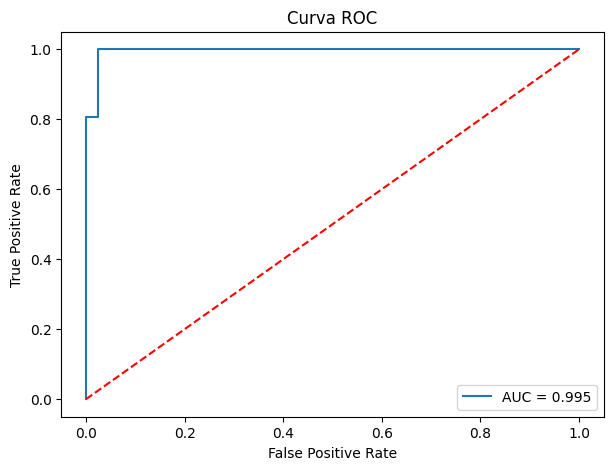

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Crear figura
plt.figure(figsize=(7, 5))

# Graficar curva ROC
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

# Línea de referencia
plt.plot([0, 1], [0, 1], 'r--')

# Etiquetas y título
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

# Mostrar gráfico
plt.show()

**K-Fold Cross Validation**

In [ ]:
# Validación cruzada con k=5 usando AUC ROC
scores_5 = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

# Mostrar el AUC promedio obtenido
print("AUC promedio k=5:", scores_5.mean())

AUC promedio k=5: 0.9924782978664407


In [ ]:
# Validación cruzada con 10 particiones
scores_10 = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=10,
    scoring='roc_auc'
)

print("AUC promedio k=10:", scores_10.mean())

AUC promedio k=10: 0.9922084793513364


**GridSearchCV y RandomizedSearchCV**

In [ ]:
# Búsqueda de hiperparámetros con GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# Probar todas las combinaciones usando validación cruzada
grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

# Entrenar la búsqueda con los datos de entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores resultados
print("Mejores parámetros:")
print(grid.best_params_)

print("Mejor score:")
print(grid.best_score_)

Mejores parámetros:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor score:
0.9936016511867904


In [ ]:
# RandomizedSearchCV para buscar hiperparámetros de forma aleatoria
from scipy.stats import uniform

# Distribución de valores para el parámetro C
param_dist = {
    'C': uniform(0.01, 100)
}

# Probar 20 combinaciones aleatorias usando validación cruzada
random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=5000),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42
)

# Entrenar la búsqueda
random_search.fit(X_train, y_train)

# Mostrar mejores resultados
print("Mejores parámetros:")
print(random_search.best_params_)

print("Mejor score:")
print(random_search.best_score_)

Mejores parámetros:
{'C': np.float64(2.0684494295802445)}
Mejor score:
0.9921568627450981


In [ ]:
# Comparar los mejores resultados de ambas búsquedas
print("GridSearch:", grid.best_score_)
print("RandomizedSearch:", random_search.best_score_)

GridSearch: 0.9936016511867904
RandomizedSearch: 0.9921568627450981


**AJUSTE DEL UMBRAL**

In [ ]:
# Definir un umbral de decisión
threshold = 0.3

# Clasificar usando el nuevo umbral
y_pred_new = (y_prob >= threshold).astype(int)

# Evaluar métricas con el umbral 0.3
print("Precision:",
      precision_score(y_test, y_pred_new))

print("Recall:",
      recall_score(y_test, y_pred_new))

print("F1:",
      f1_score(y_test, y_pred_new))


# Comparar métricas con diferentes umbrales
for threshold in [0.3, 0.5, 0.7]:

    # Generar predicciones según el umbral actual
    pred = (y_prob >= threshold).astype(int)

    print(f"\nUmbral: {threshold}")

    print(
        "Precision:",
        precision_score(y_test, pred)
    )

    print(
        "Recall:",
        recall_score(y_test, pred)
    )

    print(
        "F1:",
        f1_score(y_test, pred)
    )

Precision: 0.972972972972973
Recall: 1.0
F1: 0.9863013698630136

Umbral: 0.3
Precision: 0.972972972972973
Recall: 1.0
F1: 0.9863013698630136

Umbral: 0.5
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1: 0.9861111111111112

Umbral: 0.7
Precision: 0.9852941176470589
Recall: 0.9305555555555556
F1: 0.9571428571428572
